<center></a>
<center><font size=10>    GenAI-Driven Stock Market Prediction</center></font>

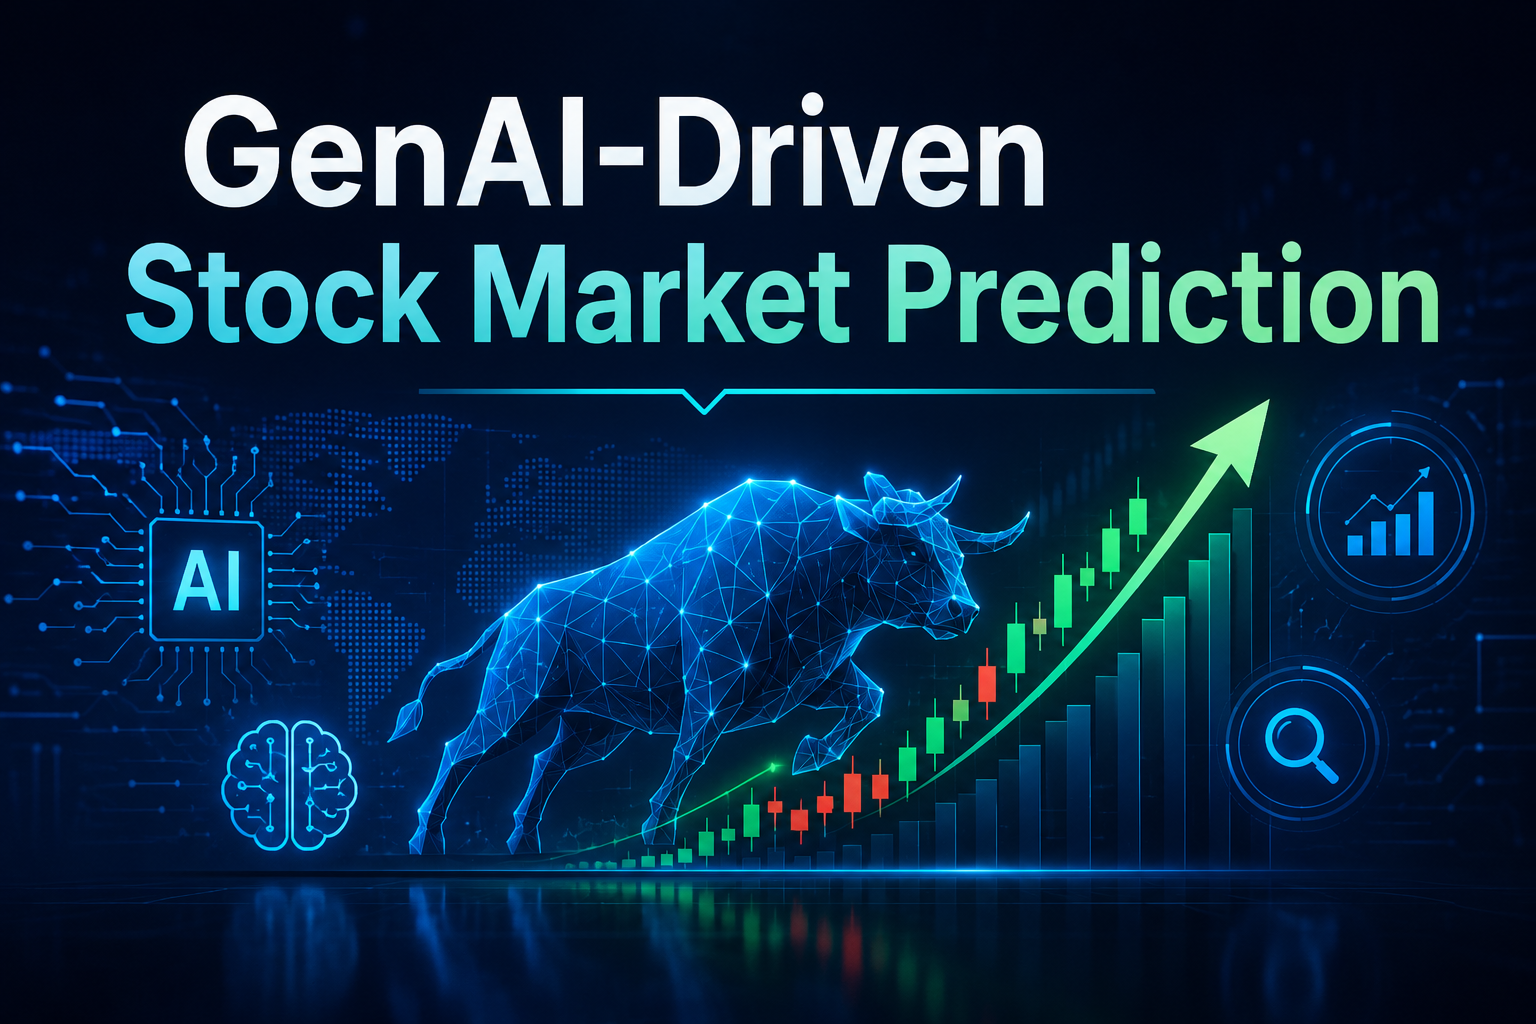

## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [ ]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstal

In [ ]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

In [ ]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading data into a pandas dataframe
News = pd.read_csv('/content/drive/MyDrive/Dataset/GenAIDataset/stock_news.csv')


In [ ]:
# creating a copy of the data
data = News.copy()

## **Data Overview**

###**Checking the first 5 rows**

In [ ]:
data.head()

###**Checking the last 5 rows**

In [ ]:
data.tail()

###**Checking the shape of the data**

In [ ]:
data.shape

###**Checking for missing values**

In [ ]:
data.isnull().sum()

### **Checking for duplicate values**

In [ ]:
# checking for duplicate values
data.duplicated().sum()

In [ ]:
# Check for duplicate rows
duplicate_rows = data[data.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")


## **Exploratory Data Analysis**

In [ ]:
# To display the structure of data
data.info()

In [ ]:
#converting object column 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])

In [ ]:
# To ensure the data type of Date
data['Date'].dtype

In [ ]:
# summary statistics for each numeric column
data.describe()

### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

In [ ]:
# Distribution of sentiment polarity
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='Label')
plt.title("Distribution of Sentiment Polarity")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

**Observations:**
- The dataset contains three sentiment classes — negative (-1), neutral (0), and positive (1) — and the counts are not perfectly balanced across the three classes.
- This class imbalance is worth keeping in mind when interpreting classification performance later, since accuracy alone can look better than it really is on imbalanced classes.

In [ ]:
# Plot Distribution of all Numeric variables
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
data[numeric_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

**Observations:**
- Open, High, Low, and Close all show similar distributions, clustered mostly in the $40-$55 range, consistent with the ~4-month (January-April 2019) window covered by this dataset.
- Volume is heavily right-skewed — most trading days have a moderate volume, while a smaller number of days show unusually high trading activity.
- The Label histogram reflects the same three-class sentiment split seen in the earlier count plot.

### **Distribution of the length of news content**

In [ ]:
# Compute length of news content (in words)
data['News_Length'] = data['News'].str.split().str.len()

# Summary statistics of news length
data['News_Length'].describe()



In [ ]:
# Plot distribution
plt.figure(figsize=(8,5))
sns.histplot(data['News_Length'], bins=30, kde=True)
plt.title("Distribution of News Length")
plt.xlabel("News Length (Words)")
plt.ylabel("Frequency")
plt.show()

**Observations:**
- News article lengths are right-skewed — most articles are relatively short, with a smaller number of longer articles extending the tail of the distribution.
- This variation in article length is useful context for the embedding step later, since both Word2Vec and Sentence Transformer embeddings need to handle documents of very different lengths.

### **Monthwise Analysis**

In [ ]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

In [ ]:
# plot the monthwise averages of all price variables for better visualization

# Extract month from Date
data['Month'] = data['Date'].dt.month_name()

# Calculate monthly average of price columns
monthly_avg = data.groupby('Month')[['Open', 'High', 'Low', 'Close']].mean()

# Arrange months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_avg = monthly_avg.reindex(month_order)

# Plot
plt.figure(figsize=(12,6))
monthly_avg.plot(marker='o')
plt.title('Month-wise Average of Price Variables')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()


* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

In [ ]:
#plot the trend of monthwise averages in Volume

# Calculate month-wise average Volume
monthly_volume = data.groupby(data['Date'].dt.month_name())['Volume'].mean()

# Arrange months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_volume = monthly_volume.reindex(month_order)

# Plot the trend
plt.figure(figsize=(12,6))
plt.plot(monthly_volume.index, monthly_volume.values, marker='o')
plt.title('Month-wise Average Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [ ]:
# Bar plot of the monthwise averages in Volume

# Calculate month-wise average Volume
monthly_volume = data.groupby(data['Date'].dt.month_name())['Volume'].mean()

# Arrange months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_volume = monthly_volume.reindex(month_order)

# Bar plot
plt.figure(figsize=(12,6))
plt.bar(monthly_volume.index, monthly_volume.values)
plt.title('Month-wise Average Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

**Observations:**
- Average trading volume fluctuates across the four months (January-April 2019) covered by the dataset, rather than following the steady upward trend seen in the price variables.
- This suggests trading volume is driven more by day-to-day news and events than by the same gradual growth pattern seen in prices.

In [ ]:
# Boxplot to identify outliers
plt.figure(figsize=(12,6))

sns.boxplot(data=data[['Open', 'High', 'Low', 'Close', 'Volume']])

plt.title('Boxplot of Numeric Variables')
plt.xlabel('Variables')
plt.ylabel('Values')
plt.show()

**Observations:**
- Since Volume is on a much larger scale (hundreds of millions) than the price variables (Open, High, Low, Close, roughly $37-$55), plotting them together on the same axis makes the price boxplots appear flat.
- Volume needs to be visualized on its own (as done in the next plot) to properly assess its spread and outliers.

In [ ]:
# Boxplot to identify single column outliers
plt.figure(figsize=(6,4))

sns.boxplot(y=data['Volume'])

plt.title('Boxplot of Volume')
plt.ylabel('Volume')
plt.show()

**Observations:**
- The Volume boxplot shows several points above the upper whisker, indicating a number of days with unusually high trading volume compared to the typical range.
- These outlier days are likely linked to major news events, earnings announcements, or other market-moving developments.

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

In [ ]:
# Correlation matrix to check if variables move together or have correlations
corr_matrix = data[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

**Observations:**
- Open, High, Low, and Close are very strongly correlated with one another (correlation close to 1), which is expected since they all move together within the same trading day.
- Volume shows a much weaker relationship with the price variables, suggesting trading volume is driven by different factors than the day's price level.

### **Sentiment Polarity vs Price**

In [ ]:
#Sentiment Polarity with all numeric variables
plt.figure(figsize=(14,8))

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Label', y=col, data=data)
    plt.title(f'Label vs {col}')

plt.tight_layout()
plt.show()

**Observations:**
- Price distributions (Open, High, Low, Close) look fairly similar across the three sentiment labels, with overlapping ranges — suggesting the price level on a given day is not, by itself, a strong indicator of that day's news sentiment.
- This reinforces the need for text-based features (via Word2Vec/Sentence Transformer embeddings) rather than price alone to classify news sentiment.

### **Time Series Analysis (Date vs Price)**

In [ ]:
#Time Series Analysis (Date vs Price columns)
plt.figure(figsize=(14,7))

plt.plot(data['Date'], data['Open'], label='Open')
plt.plot(data['Date'], data['High'], label='High')
plt.plot(data['Date'], data['Low'], label='Low')
plt.plot(data['Date'], data['Close'], label='Close')

plt.title('Time Series Analysis (Date vs Price Columns)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observations:**
- Open, High, Low, and Close track each other closely throughout the January-April 2019 period, confirming the strong correlation seen in the heatmap.
- The overall price trend is upward over the period, with some short-term dips and fluctuations along the way.

### **Distribution of News Length Across Sentiment Categories**

In [ ]:
# Calculate news length (number of words)
data['News_Length'] = data['News'].apply(lambda x: len(str(x).split()))

# Distribution of News Length Across Sentiment Categories
plt.figure(figsize=(8,6))
sns.boxplot(x='Label', y='News_Length', data=data)

plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Sentiment Category')
plt.ylabel('News Length (Words)')
plt.show()

**Observations:**
- News article length is broadly similar across the three sentiment categories, with overlapping distributions.
- This suggests sentiment is conveyed more through word choice and content than through article length alone.

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [ ]:
# Storing target variable
y = data['Label']


## **Word Embeddings**


#### **Word2Vec**

In [ ]:
from gensim.models import Word2Vec

sentences = [str(news).split() for news in data['News']]

model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

In [ ]:
# Creating a list of all words in our data
words = []

for news_item in data['News']:
    for word in str(news_item).split():
        words.append(word)

print(words[:20])

In [ ]:

# Retrieving word vectors for all the words present in the model's vocabulary
vec_size = model.vector_size

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = {}

for word in words:
    word_vector_dict[word] = model.wv[word]

In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents
word2vec_embeddings = pd.DataFrame(
    [average_vectorizer_Word2Vec(doc) for doc in data['News']]
)

word2vec_embeddings.head()

## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [ ]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

##### Encoding the dataset

In [ ]:
embedding_matrix = model.encode(
    data['News'].tolist(),
    show_progress_bar=True
)

In [ ]:
# printing the shape of the embedding matrix
embedding_matrix.shape

## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [ ]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [ ]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

In [ ]:
# Storing independent variable
X = word2vec_embeddings



In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [ ]:
# Building the model
rf_model = RandomForestClassifier(random_state=42)
# Fitting on train data
rf_model.fit(X_train, y_train)

In [ ]:
# Predicting on train data
y_pred_train = rf_model.predict(X_train)

# Predicting on test data
y_pred_test = rf_model.predict(X_test)

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

In [ ]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

###**Sentence Transformer-Random Forest Model**

In [ ]:
# Storing independent variable
X = embedding_matrix


In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

# Building the model
rf_model = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model.fit(X_train, y_train)

In [ ]:
# Predicting on train data
y_train_pred = rf_model.predict(X_train)

# Predicting on test data
y_test_pred = rf_model.predict(X_test)

In [ ]:
plot_confusion_matrix(y_train, y_train_pred)

In [ ]:
plot_confusion_matrix(y_test, y_test_pred)

In [ ]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_train_pred)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_test_pred)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

In [ ]:
# Storing independent variable
X = word2vec_embeddings

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [ ]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')   # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


In [ ]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

In [ ]:
# Predict class probabilities on training data
y_test_prob = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_prob, axis=1)

In [ ]:
# Predict class probabilities on test data
y_train_prob = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_prob, axis=1)


In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [ ]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [ ]:
X = embedding_matrix

In [ ]:

# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')   # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()

In [ ]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

In [ ]:
# Predict class probabilities on training data
y_train_prob = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_prob, axis=1)


In [ ]:
# Predict class probabilities on test data
y_test_prob = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_prob, axis=1)

In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [ ]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


#### **Generating Embeddings with Sentence Transformers using the all-MiniLM-L6-v2 embeddings**

In [ ]:
model_minilm = SentenceTransformer('all-MiniLM-L6-v2')


##### Encoding the dataset

In [ ]:
embedding_matrix_minilm = model_minilm.encode(
    data['News'].tolist(),
    show_progress_bar=True
)


In [ ]:
# printing the shape of the embedding matrix
embedding_matrix_minilm.shape


### **MiniLM-Random Forest Model**

In [ ]:
# Storing independent variable
X = embedding_matrix_minilm


In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Building the model
rf_model = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model.fit(X_train, y_train)


In [ ]:
# Predicting on train data
y_train_pred = rf_model.predict(X_train)

# Predicting on test data
y_test_pred = rf_model.predict(X_test)


In [ ]:
plot_confusion_matrix(y_train, y_train_pred)


In [ ]:
plot_confusion_matrix(y_test, y_test_pred)


In [ ]:
train_transformer_MiniLM_RF = model_performance_classification_sklearn(y_train,y_train_pred)
print("Training set performance metrics:")
print(train_transformer_MiniLM_RF.to_string(index=False))
test_transformer_MiniLM_RF = model_performance_classification_sklearn(y_test,y_test_pred)
print("Test set performance metrics:")
print(test_transformer_MiniLM_RF.to_string(index=False))


### **MiniLM-Neural Network Model**

In [ ]:
X = embedding_matrix_minilm


In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])


In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')   # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


In [ ]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)


In [ ]:
# Predict class probabilities on training data
y_train_prob = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_prob, axis=1)


In [ ]:
# Predict class probabilities on test data
y_test_prob = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_prob, axis=1)


In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds)


In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds)


In [ ]:
train_transformer_MiniLM_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_MiniLM_NN.to_string(index=False))
test_transformer_MiniLM_NN = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_MiniLM_NN.to_string(index=False))


### **Model Performance Summary and Final Model Selection**

In [ ]:

# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        train_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

In [ ]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        test_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

In [ ]:
print("Final Model Selection: Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)")
print(models_test_comp_df[["Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)"]].to_string())

## **News Summarization**

### **Weekly News Aggregation**

In [ ]:
# Create a Week column to group news at a weekly level
data['Week'] = data['Date'].dt.to_period('W').astype(str)

# Combine all news articles within the same week into one text block
weekly_news = (
    data.groupby('Week')['News']
        .apply(lambda x: ' '.join(x.astype(str)))
        .reset_index()
)

weekly_news.head()


### **Generating Summaries using T5**

In [ ]:
# Loading the T5 tokenizer and model
tokenizer = T5Tokenizer.from_pretrained('t5-small')
model_t5 = T5ForConditionalGeneration.from_pretrained('t5-small')

summarizer = pipeline(
    "summarization",
    model=model_t5,
    tokenizer=tokenizer
)


In [ ]:
def summarize_text(text, max_len=150, min_len=40):
    # T5 has an input token limit, so truncate long text before summarizing
    text = text[:3000]
    summary = summarizer(text, max_length=max_len, min_length=min_len, do_sample=False)
    return summary[0]['summary_text']

# Generating a summary for each week's combined news
weekly_news['Weekly_Summary'] = weekly_news['News'].apply(summarize_text)


In [ ]:
# Viewing the weekly summaries
weekly_news[['Week', 'Weekly_Summary']].head(10)


## **Conclusions and Recommendations**

#### **Conclusions**

## Conclusion

In this project, Word2Vec and Sentence Transformer embeddings were used to convert text into meaningful numerical representations for sentiment analysis. Word2Vec captured semantic relationships between words based on this dataset alone, while Sentence Transformers (BAAI/bge-base-en-v1.5) generated context-aware sentence embeddings, pretrained on large external corpora, that better represented the overall meaning of the text.

The generated embeddings were used to train two machine learning models: Random Forest and Neural Networks. Random Forest achieved perfect training performance (Accuracy/F1 = 1.0) with both embedding types, but this came at the cost of significant overfitting — test accuracy dropped to ~45-50%, showing the model memorized the training data rather than learning generalizable patterns. The Neural Network models, particularly with Sentence Transformer embeddings, showed a smaller train-test gap and achieved the best overall test performance (Accuracy ~52.9%, F1 ~0.52), indicating better generalization to unseen news articles.

Across both model types, Sentence Transformer embeddings consistently outperformed Word2Vec embeddings on the test set, confirming that pretrained, context-aware embeddings add meaningful value over embeddings trained from scratch on a relatively small news dataset.

Overall, the project shows that combining modern text embedding methods with machine learning models can effectively classify sentiment from textual data, while also highlighting the importance of addressing overfitting and dataset size for more reliable real-world performance. The weekly news summarization component further complements this by giving analysts quick, readable context alongside the sentiment signal, supporting more informed investment decisions.

**Models used:**

**Word2Vec**

**Sentence Transformer embeddings**

**Neural Networks**

**Random Forest**

#### **Recommendations**

## Recommendations

* Fine-tune the Sentence Transformer (BAAI/bge-base-en-v1.5) embeddings on domain-specific financial/stock-news text to improve sentiment classification performance further.
* Address overfitting in the Random Forest models (which achieved a perfect 1.0 on training data but dropped to ~45-50% on test data) using techniques such as limiting `max_depth`, tuning `min_samples_leaf`, and applying cross-validation instead of a single train-test split.
* Increase the size and diversity of the dataset to improve the model's ability to generalize to unseen data.
* Perform hyperparameter tuning for both Random Forest and Neural Network models to achieve better accuracy and robustness (e.g., Dropout and L2 regularization for the Neural Network to reduce the train-test performance gap).
* Experiment with additional text embedding techniques and compare their performance with Word2Vec and Sentence Transformer embeddings.
* Apply advanced text preprocessing techniques, such as handling emojis, slang, abbreviations, and spelling corrections, to improve text quality.
* Evaluate the models using additional performance metrics, such as ROC-AUC, alongside Accuracy, Precision, Recall, and F1-Score, for a more comprehensive comparison.
* Deploy the best-performing model (Sentence Transformer + Neural Network) as a web application or API for real-time sentiment prediction.
* Use the weekly news summaries alongside the sentiment predictions in analyst dashboards, so users get both context ("what happened") and signal ("how the market may feel about it").
* Continuously update and retrain the model with new data to maintain performance as language usage, market conditions, and news trends evolve.